In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [177]:
ratail_df=pd.read_csv(r"C:\Users\91990\Downloads\dataset\data.csv")

In [178]:
ratail_df.head()

,Unnamed: 0,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [179]:
ratail_df.shape

(525461, 9)

In [180]:
ratail_df.columns

Index(['Unnamed: 0', 'Invoice', 'StockCode', 'Description', 'Quantity',
       'InvoiceDate', 'Price', 'Customer ID', 'Country'],
      dtype='object')

In [181]:
df_ratail=ratail_df.copy()

In [182]:
df_ratail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   525461 non-null  int64  
 1   Invoice      525461 non-null  object 
 2   StockCode    525461 non-null  object 
 3   Description  522533 non-null  object 
 4   Quantity     525461 non-null  int64  
 5   InvoiceDate  525461 non-null  object 
 6   Price        525461 non-null  float64
 7   Customer ID  417534 non-null  float64
 8   Country      525461 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 36.1+ MB


In [183]:
df_ratail.isna().sum()

Unnamed: 0          0
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [184]:
df_ratail.drop("Unnamed: 0", axis=1,inplace=True)

In [185]:
df_ratail.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [186]:
df_ratail['Customer ID'].unique

<bound method Series.unique of 0         13085.0
1         13085.0
2         13085.0
3         13085.0
4         13085.0
           ...   
525456    17530.0
525457    17530.0
525458    17530.0
525459    17530.0
525460    17530.0
Name: Customer ID, Length: 525461, dtype: float64>

In [187]:
df_ratail['Customer ID']=df_ratail['Customer ID'].ffill()

In [188]:
df_ratail.isna().sum()

Invoice           0
StockCode         0
Description    2928
Quantity          0
InvoiceDate       0
Price             0
Customer ID       0
Country           0
dtype: int64

In [189]:
df_ratail['Description'].unique()

array(['15CM CHRISTMAS GLASS BALL 20 LIGHTS', 'PINK CHERRY LIGHTS',
       ' WHITE CHERRY LIGHTS', ..., '*Boombox Ipod Classic', 'faulty',
       'Dotcom sales'], shape=(4682,), dtype=object)

In [190]:
df_ratail['Description']=df_ratail['Description'].fillna("Unknown")

In [191]:
df_ratail.isna().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [192]:
(df_ratail["Description"]=="Unknown").sum()

np.int64(2928)

In [193]:
for i in (df_ratail['StockCode'].unique()):
    print(i)

85048
79323P
79323W
22041
21232
22064
21871
21523
22350
22349
22195
22353
48173C
21755
21754
84879
22119
22142
22296
22295
22109
22107
22194
35004B
82582
21181
21756
21333
84596F
84596L
22111
22143
22145
22130
21364
21360
21351
21352
35400
20695
37370
10002
84507B
20703
21987
21989
84970S
20971
22271
22272
22274
21912
22112
21329
21252
21100
21033
20711
21410
21411
84031A
84031B
84032A
84032B
84519A
84519B
85132A
85132C
85183A
85183B
22065
22138
22139
22352
85014A
85014B
16161P
16169N
21491
22333
85216
21493
21731
85232B
84691
20749
POST
22321
84029E
21955
84899E
85123A
21582
21586
21590
22091
84251J
22024
22026
22029
22025
22031
21428
21430
21916
21790
21888
85178
20754
21035
82001S
82580
85150
21041
35916C
35916B
22180
22128
22163
35951
22253
84988
22219
18097C
21299
21099
21085
21929
22241
21091
21733
22178
22125
21671
22086
22294
22199
22083
22114
21485
21928
85099B
22356
20724
21592
20725
20728
20726
21217
85066
20827
20825
20823
20826
22087
85206A
21895
21896
84946
22090
90200A
9

In [194]:
df_ratail['StockCode'].dtypes

dtype('O')

In [195]:
bad_codes = ["POST", "D", "M", "BANK CHARGES", "ADJUSTMENT", "DOT"]
df_ratail= df_ratail[~df_ratail['StockCode'].isin(bad_codes)]


In [196]:
df_ratail = df_ratail[df_ratail['StockCode'].astype(str).str.match("^[A-Za-z0-9]+$")]



In [197]:
df_ratail=df_ratail[df_ratail['StockCode'].str.len() >2 ]

In [198]:
df_ratail = df_ratail[~df_ratail['Description'].str.contains("postage|charges|refund", case=False, na=False)]

In [199]:
top_products = (
    df_ratail.groupby(["StockCode", "Description"])["Price"]
    .sum()
    .reset_index()
    .sort_values("Price", ascending=False)
    .head(10)
)
top_products


,StockCode,Description,Price
6915,AMAZONFEE,AMAZON FEE,79739.16
2704,22423,REGENCY CAKESTAND 3 TIER,31386.40
6133,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10681.06
1842,21754,HOME BUILDING BLOCK WORD,9093.20
1958,21843,RED RETROSPOT CAKE STAND,8909.26
4862,84078A,SET/4 WHITE RETRO STORAGE CUBES,8546.01
1640,21621,VINTAGE UNION JACK BUNTING,7813.55
1843,21755,LOVE BUILDING BLOCK WORD,7607.35
6913,ADJUST,Adjustment by john on 26/01/2010 17,7364.04
1152,21258,VICTORIAN SEWING BOX LARGE,7175.08


In [200]:
if 'Quantity' in df_ratail.columns:
    df_ratail=df_ratail[df_ratail['Quantity'] > 0]

if 'Price' in df_ratail.columns:
    df_ratail=df_ratail[df_ratail["Price"] > 0]

In [201]:
df_ratail['Revenue']=df_ratail["Quantity"]*df_ratail['Price']

In [202]:
df_ratail[['Revenue','Price','Quantity']].head(10)

,Revenue,Price,Quantity
0,83.4,6.95,12
1,81.0,6.75,12
2,81.0,6.75,12
3,100.8,2.10,48
4,30.0,1.25,24
5,39.6,1.65,24
6,30.0,1.25,24
7,59.5,5.95,10
8,30.6,2.55,12
9,45.0,3.75,12


In [203]:
total_revenue=df_ratail['Revenue'].min()
total_revenue

np.float64(0.001)

In [204]:
df_ratail['InvoiceDate'].dtypes

dtype('O')

In [205]:
total_customers=df_ratail['Customer ID'].nunique()
total_customers

4300

In [207]:
df_ratail['InvoiceDate']=pd.to_datetime(df_ratail['InvoiceDate'])
df_ratail['Month']=df_ratail['InvoiceDate'].dt.to_period('M').astype(str)

In [208]:
monthly_rev=df_ratail.groupby("Month")['Revenue'].sum().reset_index().sort_values('Month')
monthly_rev

,Month,Revenue
0,2009-12,801216.470
1,2010-01,622838.742
2,2010-02,539744.686
3,2010-03,764333.851
4,2010-04,649016.322
5,2010-05,645645.390
6,2010-06,700047.070
7,2010-07,634880.860
8,2010-08,676060.720
9,2010-09,871878.341


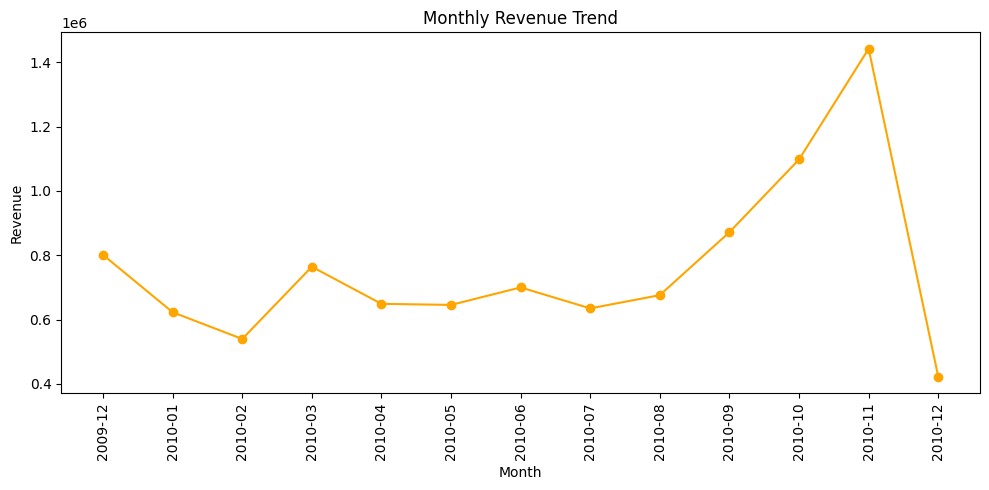

In [227]:
plt.figure(figsize=[10,5])

plt.plot(monthly_rev['Month'], monthly_rev['Revenue'], color='Orange', marker='o')
plt.xticks(rotation=90)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [239]:
country_rev=df_ratail.groupby('Country')['Revenue'].sum().reset_index().sort_values('Revenue',ascending=False)
country_rev.head(10)

,Country,Revenue
37,United Kingdom,8514139.993
10,EIRE,359387.700
24,Netherlands,266063.320
13,Germany,183390.101
12,France,132422.790
9,Denmark,50348.850
32,Sweden,49513.710
31,Spain,43115.430
33,Switzerland,41182.390
0,Australia,30313.350


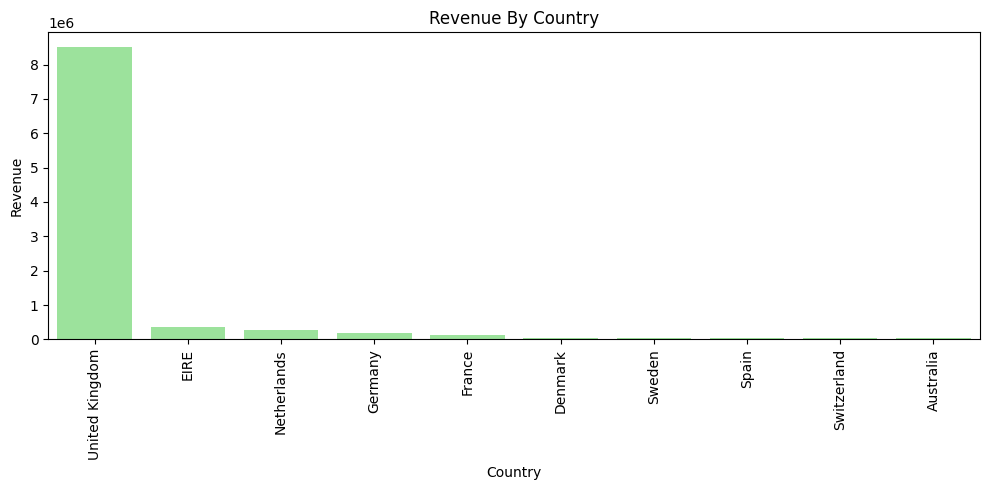

In [241]:
top_10=country_rev.head(10)
plt.figure(figsize=[10,5])
sns.barplot(data=top_10, x='Country',y='Revenue',color='lightgreen')
plt.xticks(rotation=90)
plt.title("Revenue By Country")
plt.xlabel('Country')
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [243]:
top_products=df_ratail.groupby(['StockCode','Description'])['Revenue'].sum().reset_index().sort_values("Revenue", ascending=False)

top_products.head(10)

,StockCode,Description,Revenue
1858,22423,REGENCY CAKESTAND 3 TIER,170078.51
4113,85123A,WHITE HANGING HEART T-LIGHT HOLDER,158590.87
3772,84879,ASSORTED COLOUR BIRD ORNAMENT,73092.99
1457,22086,PAPER CHAIN KIT 50'S CHRISTMAS,58189.25
4082,85099B,JUMBO BAG RED RETROSPOT,54483.87
2883,47566,PARTY BUNTING,49682.72
3366,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,47985.09
24,15056N,EDWARDIAN PARASOL NATURAL,36251.10
1047,21621,VINTAGE UNION JACK BUNTING,36125.71
4086,85099F,JUMBO BAG STRAWBERRY,35918.34


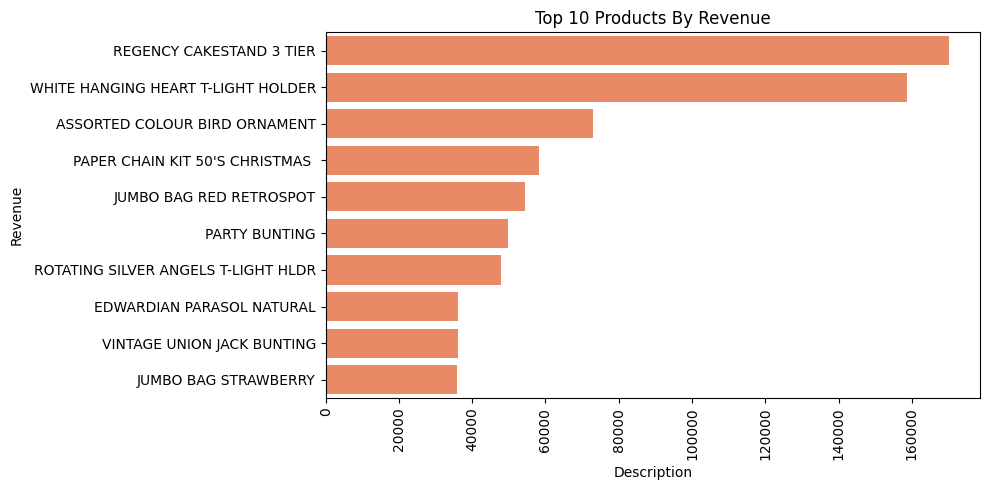

In [255]:
topp_10=top_products.head(10)

plt.figure(figsize=[10,5])
sns.barplot(data=topp_10, x='Revenue', y='Description', color='coral')
plt.xticks(rotation=90)
plt.title("Top 10 Products By Revenue")
plt.ylabel('Revenue')
plt.xlabel("Description")
plt.tight_layout()
plt.show()

In [264]:
order_value=df_ratail.groupby('Invoice')['Revenue'].sum().reset_index().sort_values("Revenue", ascending=False)
order_value.head(10)

,Invoice,Revenue
18333,533027,49844.99
17673,531516,45332.97
1771,493819,44051.60
14511,524181,33167.80
15781,526934,26007.08
10856,515944,22863.36
5447,503061,22853.77
11657,517731,21984.00
2464,495591,18570.88
1958,494243,18532.30


Text(0, 0.5, 'Revenue')

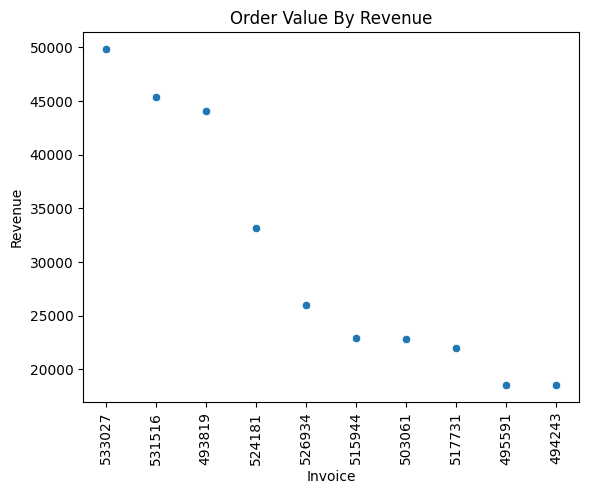

In [272]:
top=order_value.head(10)

sns.scatterplot(data=top, x='Invoice', y='Revenue')
plt.xticks(rotation=90)
plt.title("Order Value By Revenue")
plt.xlabel("Invoice")
plt.ylabel("Revenue")

In [283]:
numeric=['Quantity','Price','Revenue']


def cap_outliers(i):
    q1=df_ratail[i].quantile(0.25)
    q3=df_ratail[i].quantile(0.75)

    iqr =q3-q1

    lower=q1-(1.5*iqr)
    higher=q3+(1.5*iqr)

    df_ratail[i]=np.where(df_ratail[i]<lower,lower, np.where(df_ratail[i]>higher,higher, df_ratail[i]))

for i in numeric:
    cap_outliers(i)


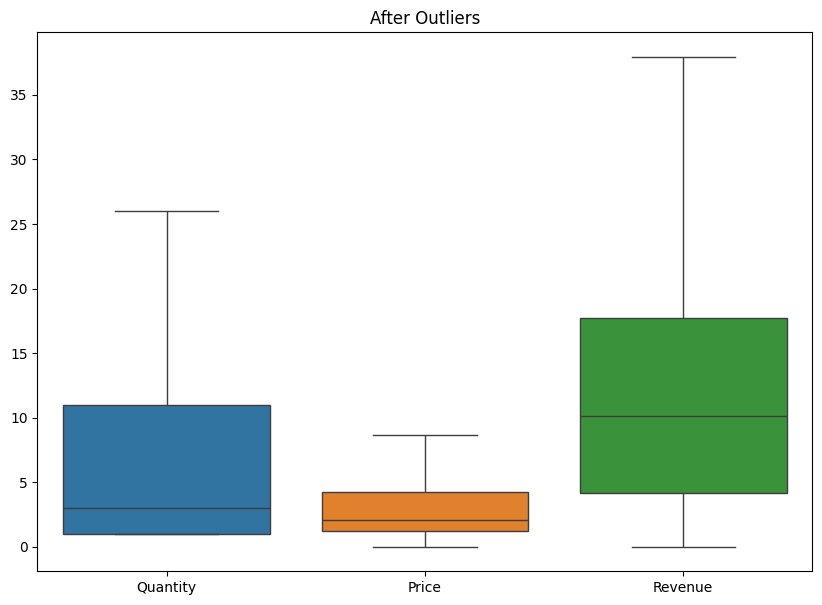

In [287]:
plt.figure(figsize=[10,7])
sns.boxplot(data=df_ratail[numeric])
plt.title("After Outliers")
plt.show()

In [293]:
categorical_col=df_ratail.select_dtypes(include='object').columns
categorical_col

Index(['Invoice', 'StockCode', 'Description', 'Country', 'Month'], dtype='object')

In [291]:
for i in categorical_col:
    print(f"\ncolumns : {i}")
    print(df_ratail[i].value_counts())


columns : Invoice
Invoice
537434    674
538071    650
537638    600
537237    596
536876    592
         ... 
489608      1
489611      1
489613      1
489618      1
489634      1
Name: count, Length: 20624, dtype: int64

columns : StockCode
StockCode
85123A    3421
22423     2044
85099B    2012
21212     1920
21232     1713
          ... 
90135        1
37477C       1
90142B       1
90176B       1
90127A       1
Name: count, Length: 4235, dtype: int64

columns : Description
Description
WHITE HANGING HEART T-LIGHT HOLDER    3455
REGENCY CAKESTAND 3 TIER              2044
STRAWBERRY CERAMIC TRINKET BOX        1713
PACK OF 72 RETRO SPOT CAKE CASES      1456
ASSORTED COLOUR BIRD ORNAMENT         1449
                                      ... 
AMBER 3 BEAD DROP EARRINGS               1
DIAMANTE NECKLACE BLACK                  1
MOP PENDANT SHELL NECKLACE               1
BAKING MOULD EASTER EGG MILK CHOC        1
*Boombox Ipod Classic                    1
Name: count, Length: 4519, dtype: 

In [ ]:
df_ratail['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'EIRE', 'Germany',
       'Portugal', 'Denmark', 'Netherlands', 'Poland', 'Channel Islands',
       'Spain', 'Cyprus', 'Belgium', 'Greece', 'Norway', 'Austria',
       'Sweden', 'United Arab Emirates', 'Finland', 'Italy',
       'Switzerland', 'USA', 'Japan', 'Unspecified', 'Nigeria', 'Malta',
       'Bahrain', 'RSA', 'Bermuda', 'Hong Kong', 'Singapore', 'Thailand',
       'Israel', 'Lithuania', 'West Indies', 'Lebanon', 'Korea', 'Brazil',
       'Canada', 'Iceland'], dtype=object)

In [315]:
data=df_ratail.groupby('Country')['Revenue'].sum().reset_index().sort_values('Revenue', ascending=False)
data.head()

,Country,Revenue
37,United Kingdom,5809852.523
10,EIRE,198188.510
13,Germany,144568.731
12,France,99375.070
24,Netherlands,70316.630


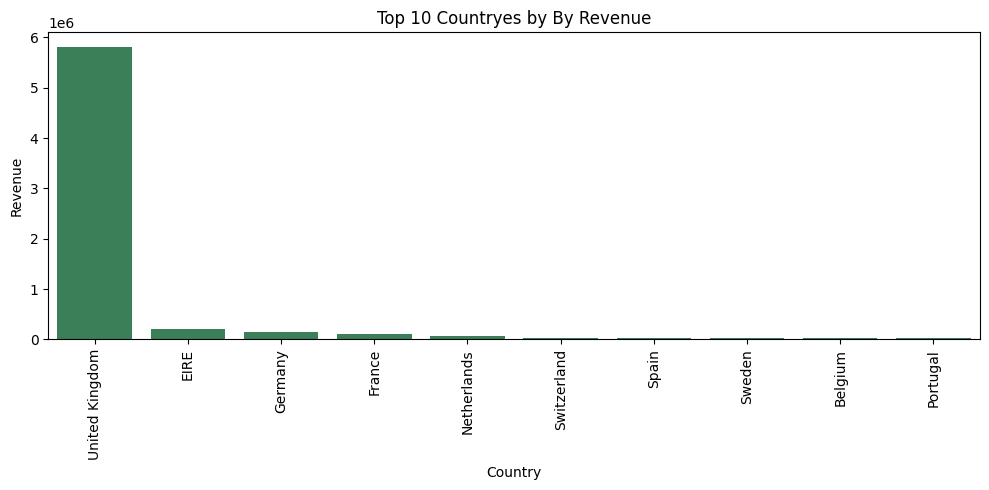

In [317]:
top10=data.head(10)

plt.figure(figsize=[10,5])
sns.barplot(data=top10, x='Country', y='Revenue', color='seagreen')
plt.title("Top 10 Countryes by By Revenue")
plt.xticks(rotation=90)
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

In [324]:
quantity_sold=df_ratail.groupby("Month")['Quantity'].sum().reset_index().sort_values('Quantity',ascending=False)
quantity_sold.head(10)


,Month,Quantity
11,2010-11,479804.0
10,2010-10,422021.0
9,2010-09,322808.0
3,2010-03,271836.0
0,2009-12,266698.0
6,2010-06,259881.0
8,2010-08,245854.0
5,2010-05,240871.0
4,2010-04,238820.0
7,2010-07,233825.0


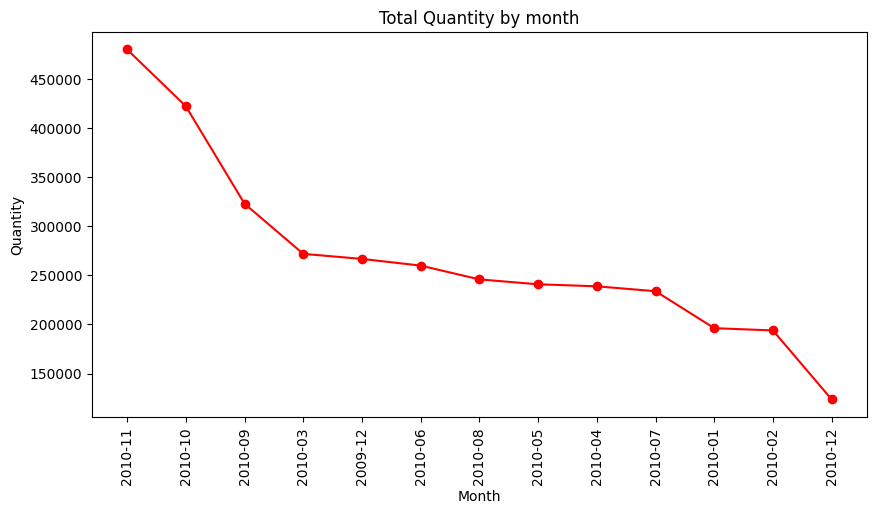

In [328]:
plt.figure(figsize=[10,5])
plt.plot(quantity_sold['Month'],quantity_sold['Quantity'],color='red',marker='o')
plt.xticks(rotation=90)
plt.title("Total Quantity by month")
plt.xlabel("Month")
plt.ylabel("Quantity")
plt.show()

## 1. Revenue Concentration

### A few products generate most of the revenue.

### Example: Top 10–20 products dominate sales.

## 2. Customer Concentration

### Very few customers buy repeatedly.

### Many customers buy only once.

## 3. Seasonal Trend

### Sales peak in some months (festivals/holidays).

### Some months have very low sales.

## 4. Country Pattern

### UK customers buy the most.

### Other countries contribute less volume.

## 5. Product Strategy

### Most high-selling products are low–mid price.

### Expensive items sell less frequently.


# Conclusion :-

### In my retail analytics project, I found that revenue is highly concentrated. A small group of products generated the majority of total sales, which shows a strong 80/20 effect.
### I observed that most revenue came from a few repeat customers, while many customers purchased only once.
### Sales showed monthly variation, with clear peak periods compared to low months. Based on these insights, I would recommend focusing inventory on top-selling products and improving customer retention strategies.